In [2]:
import pandas as pd

data = {
    "Artist": ["Claude Monet", "Rembrandt", "Pablo Picasso", "Edgar Degas", "Vincent van Gogh", "Henri Matisse", "Pierre-Auguste Renoir", "Paul Cézanne", "Georgia O'Keeffe", "Berthe Morisot"],
    "Count": [11, 9, 8, 8, 7, 6, 5, 3, 3, 3]
}

df = pd.DataFrame(data)

In [3]:
import rpy2.ipython
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/luizaswierzawska1/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <B96A8100-FA7A-3EFC-8726-931D26646DE6> /Users/luizaswierzawska1/.pyenv/versions/3.13.9/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


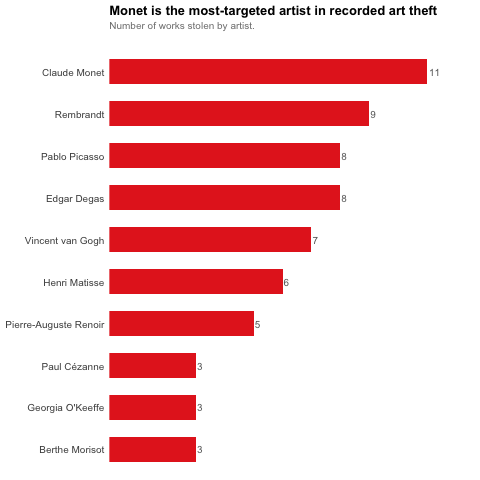

In [9]:
%%R -i df

library(tidyverse)
library(ggplot2)

df <- df %>% mutate(Artist = reorder(Artist, Count))

ggplot(df, aes(x = Count, y = Artist)) +
  geom_col(fill = "#E52A22", width = 0.6) +
  geom_text(
    aes(label = Count),
    hjust = -0.2,
    size = 3.5,
    color = "grey40"
  ) +
  scale_x_continuous(
    expand = expansion(mult = c(0, 0.15))
  ) +
  labs(
    title = "Monet is the most-targeted artist in recorded art theft",
    subtitle = "Number of works stolen by artist.",
    x = NULL,
    y = NULL
  ) +
  theme_minimal() +
  theme(
    plot.title = element_text(size = 13, face = "bold", margin = margin(b = 4)),
    plot.subtitle = element_text(size = 10, color = "grey50", margin = margin(b = 16)),
    plot.caption = element_text(size = 8, color = "grey60", hjust = 0),
    axis.text.y = element_text(size = 10, color = "grey30"),
    axis.text.x = element_blank(),
    axis.ticks = element_blank(),
    panel.grid = element_blank(),
    plot.background = element_blank(),
    panel.background = element_blank()
  )

In [ ]:
%%R
ggsave("bar_chart.svg", units = "in")